# 预测性维护：机器故障分类建模

本 Notebook 基于 `predictive_maintenance.csv`，使用机器运行时的传感器数据预测机器是否会发生故障。

## 整体流程
1. **数据探索**：了解数据分布、缺失值、目标变量是否平衡
2. **数据预处理**：去掉标签泄漏列，对数值特征标准化，对类别特征 one-hot 编码
3. **模型训练**：逻辑回归 + 随机森林
4. **模型评估**：准确率、精确率、召回率、F1、混淆矩阵
5. **特征重要性分析**：找出最关键的传感器

> **注意**：这份数据里的 `TWF / HDF / PWF / OSF / RNF` 是故障原因的细分标签，它们和 `Machine failure` 高度绑定，不能直接当作输入特征，否则会出现“标签泄漏”。


## 1. 导入依赖

这里导入数据分析、可视化、建模和评估常用的库：

- `pandas` / `numpy`：数据处理
- `matplotlib` / `seaborn`：画图
- `sklearn`：机器学习工具（预处理、模型、评估指标）
- `%matplotlib inline`：让图表直接显示在 Notebook 里


In [49]:

# 1. 导入依赖库
import warnings
warnings.filterwarnings('ignore')  # 忽略一些不影响结果的警告

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 让图表在 Notebook 中直接显示
%matplotlib inline
sns.set_style('whitegrid')  # 统一图表风格

# scikit-learn 相关工具
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)


## 2. 加载数据

读取 CSV 文件，查看数据的基本面貌。`pd.read_csv()` 会把表格数据读成一个 DataFrame。


In [50]:

# 2. 读取数据
# 因为 Notebook 和 CSV 文件放在同一个文件夹里，所以直接用文件名即可
df = pd.read_csv('predictive_maintenance.csv')

print('数据形状（行数, 列数）：', df.shape)
print('\n前 5 行：')
df.head()


数据形状（行数, 列数）： (10000, 12)

前 5 行：


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. 数据探索（EDA）

建模前先了解数据：有没有缺失、目标变量长什么样、各特征分布如何。这一步能帮我们发现异常、选择处理方式。


### 3.1 基本信息与缺失值

- `shape`：看有多少行、多少列
- `dtypes`：看每列的数据类型
- `isnull().sum()`：统计每列缺失值个数
- `duplicated().sum()`：统计重复行数

缺失值和重复行会影响模型训练，所以先检查清楚。


In [51]:

# 3.1 查看数据形状、列类型、缺失值、重复行
print('数据形状：', df.shape)
print('\n列类型：')
print(df.dtypes)

# 缺失值检查
print('\n缺失值统计：')
print(df.isnull().sum())

# 重复行检查
print('\n重复行数：', df.duplicated().sum())


数据形状： (10000, 12)

列类型：
Type                       str
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
TWF                      int64
HDF                      int64
PWF                      int64
OSF                      int64
RNF                      int64
dtype: object

缺失值统计：
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

重复行数： 0


### 3.2 目标变量分布

目标 `Machine failure` 只有两种取值：
- `0`：机器正常
- `1`：机器故障

如果两类样本数量差距很大（比如故障样本极少），就叫做**类别不平衡**，这时不能只看准确率。


Machine failure 分布：
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure 占比：
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


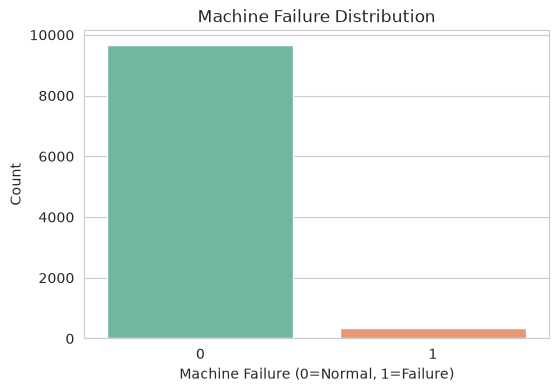

In [52]:

# 3.2 统计目标变量分布
print('Machine failure 分布：')
print(df['Machine failure'].value_counts())

print('\nMachine failure 占比：')
print(df['Machine failure'].value_counts(normalize=True).round(4))

# 可视化目标分布
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('Machine Failure Distribution')
plt.xlabel('Machine Failure (0=Normal, 1=Failure)')
plt.ylabel('Count')
plt.show()


### 3.3 数值特征的统计描述

`describe()` 可以快速得到每个数值特征的：
- 均值、标准差
- 最小值、最大值
- 四分位数

这能帮我们判断特征的量级是否一致，以及有没有异常值。


In [53]:

# 3.3 定义数值特征列并查看统计描述
numeric_features = [
    'Air temperature', 'Process temperature', 'Rotational speed',
    'Torque', 'Tool wear'
]

df[numeric_features].describe()


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


### 3.4 按故障状态看各传感器分布

把每个数值特征按 `Machine failure` 分组画直方图：
- 如果两类分布重叠很多，说明这个特征区分能力弱
- 如果分布明显分开，说明这个特征对判断故障有帮助

这里用半透明叠加的方式展示，避免样本量差距大导致看不清。


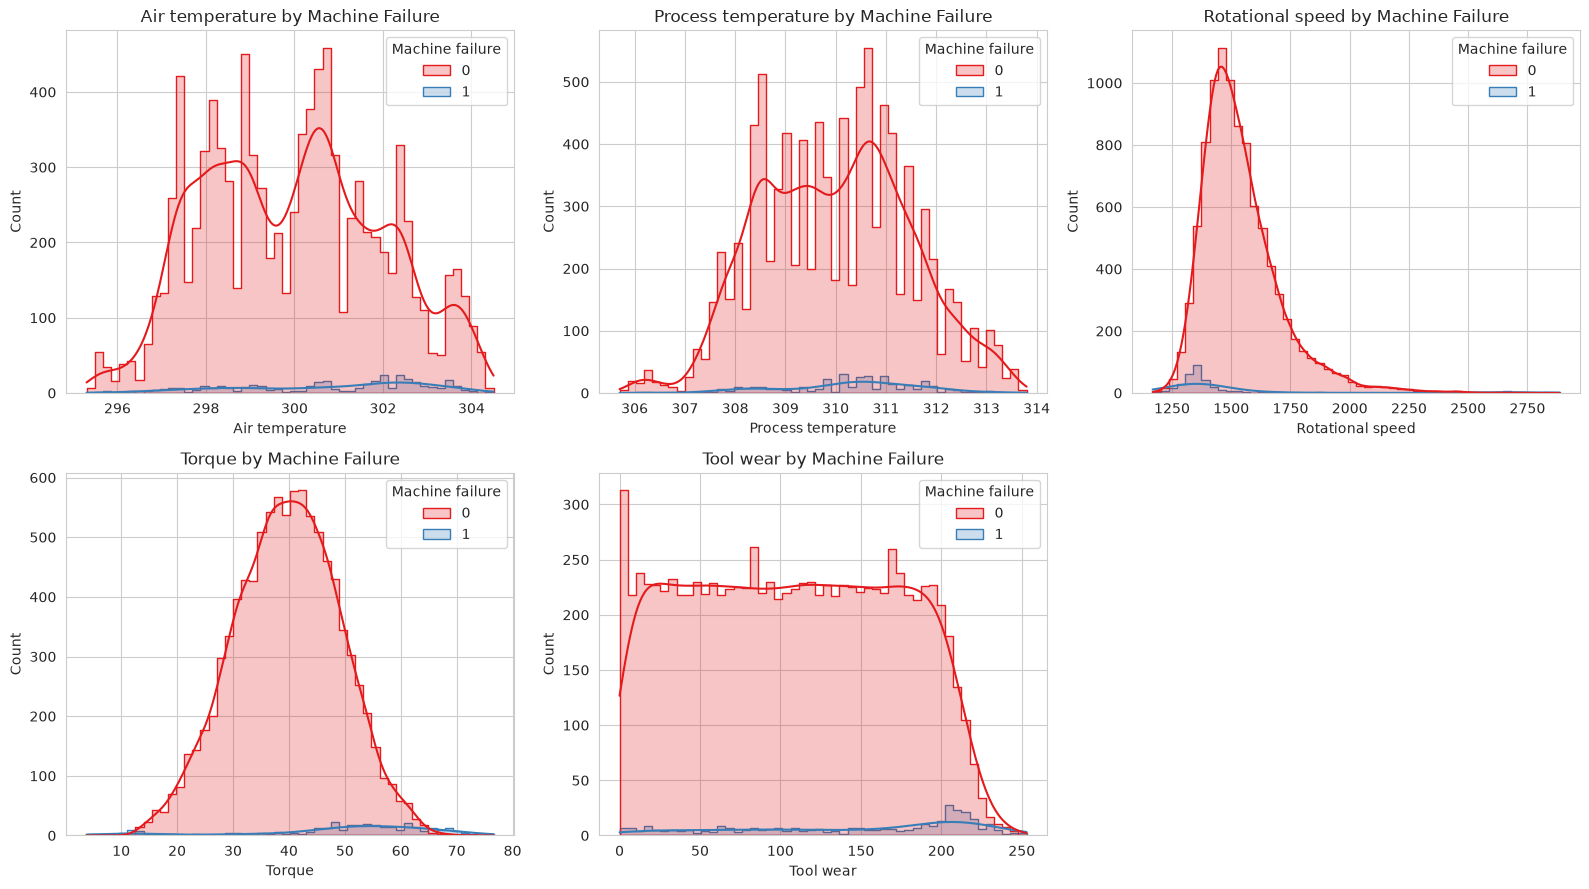

In [54]:

# 3.4 画出每个数值特征在“正常”和“故障”两类下的分布
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    sns.histplot(
        data=df, x=col, hue='Machine failure', bins=50,
        kde=True, ax=axes[idx], palette='Set1', element='step'
    )
    axes[idx].set_title(f'{col} by Machine Failure')

# 第 6 个子图没有内容，关闭它
axes[-1].axis('off')

plt.tight_layout()
plt.show()


### 3.5 产品类型与故障的关系

`Type` 表示产品质量等级（L=Low, M=Medium, H=High）。不同等级的产品设计参数不同，故障率可能也不一样。


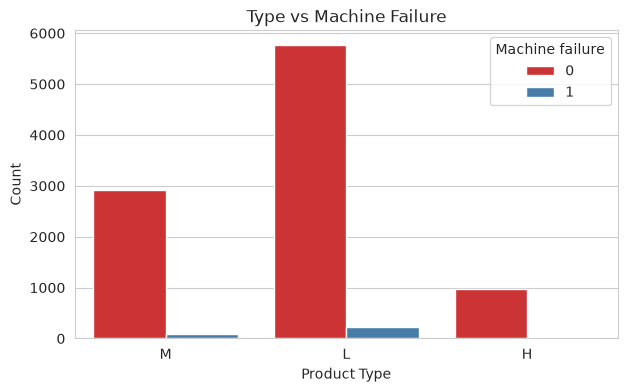

In [55]:

# 3.5 画 Type 与 Machine failure 的计数图
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Type', hue='Machine failure', palette='Set1')
plt.title('Type vs Machine Failure')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.show()


### 3.6 特征相关性热力图

相关性系数范围是 -1 到 1：
- 越接近 1，两个特征越同向变化
- 越接近 -1，越反向变化
- 越接近 0，越没有线性关系

这里主要看各特征与 `Machine failure` 的相关性强弱。


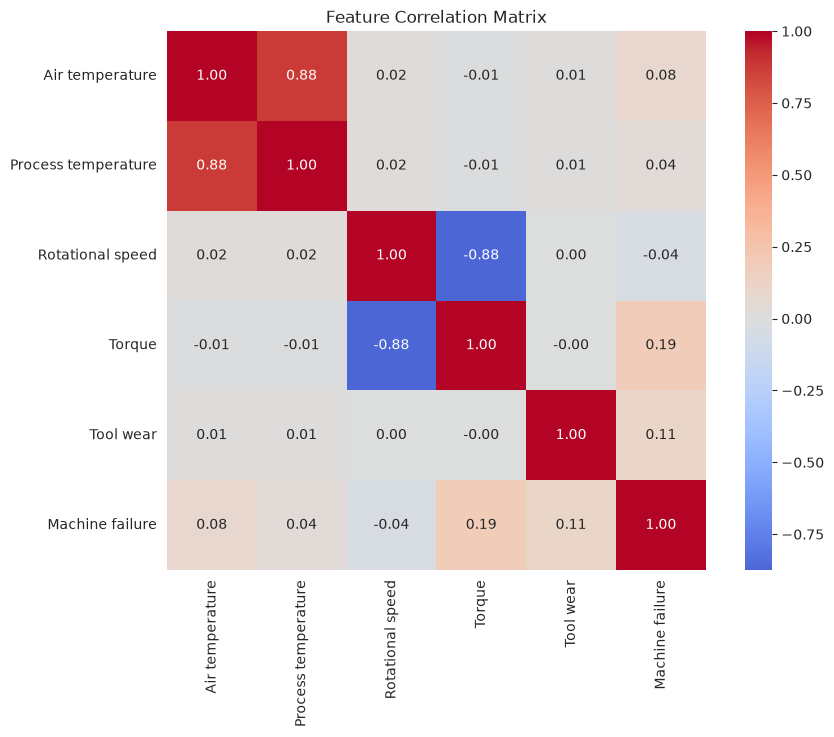

In [56]:

# 3.6 计算数值特征与目标的相关性并画热力图
plt.figure(figsize=(10, 7))
corr_cols = numeric_features + ['Machine failure']

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,      # 在格子里显示数字
    fmt='.2f',       # 保留两位小数
    cmap='coolwarm', # 颜色方案
    center=0,        # 以 0 为中心
    square=True
)
plt.title('Feature Correlation Matrix')
plt.show()


## 4. 特征工程与预处理

在建模之前，要先确定：
1. **哪些列能作为输入特征**（不能泄露目标信息）
2. **数值特征要不要标准化**
3. **类别特征要不要编码**


### 4.1 为什么要删除 TWF / HDF / PWF / OSF / RNF？

这几列表示**具体发生了哪种故障模式**。根据数据集定义：

> 只要 `TWF`、`HDF`、`PWF`、`OSF`、`RNF` 中任意一个为 1，`Machine failure` 就为 1。

也就是说，它们和 `Machine failure` 是**因果关系**。

如果把它们当作输入特征，模型就等同于“提前知道了部分答案”，这叫**标签泄漏（Data Leakage）**。训练时分数会很好看，但到真实预测时根本不知道这些故障模式会发生，模型就失去了实用价值。

所以建模时只保留机器正常运行时就能观测到的数据：`Type` 和五个数值传感器。


In [57]:

# 4.1 定义输入特征 X 和预测目标 y

# 这些列属于标签泄漏，不能作为输入特征
leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']

# X：输入特征（去掉泄漏列）
X = df.drop(columns=leakage_cols)

# y：预测目标
y = df['Machine failure']

print('输入特征列：', X.columns.tolist())
print('\n目标变量分布：')
print(y.value_counts(normalize=True).round(4))


输入特征列： ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']

目标变量分布：
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


### 4.2 划分训练集和测试集

把数据分成两部分：
- **训练集（80%）**：用来训练模型
- **测试集（20%）**：用来评估模型在“没见过”的数据上表现如何

由于故障样本很少，划分时要使用 `stratify=y`，保证训练集和测试集中的故障比例一致。否则测试集里可能只有几个故障样本，没法准确评估。


In [58]:

# 4.2 划分训练集和测试集
# test_size=0.2 表示 20% 作为测试集
# stratify=y 保证训练/测试集中故障比例一致
# random_state=42 保证每次运行结果可复现
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'训练集大小：{len(X_train)}，测试集大小：{len(X_test)}')
print(f'训练集故障率：{y_train.mean():.4f}')
print(f'测试集故障率：{y_test.mean():.4f}')


训练集大小：8000，测试集大小：2000
训练集故障率：0.0339
测试集故障率：0.0340


### 4.3 构建预处理流水线

不同的特征需要不同的处理方式：

| 特征类型 | 处理方式 | 原因 |
|---|---|---|
| 数值特征（温度、转速、扭矩等） | `StandardScaler` 标准化 | 把不同量纲的特征缩放到同一数量级，避免“数值大的特征”对模型产生过大影响 |
| 类别特征 `Type` | `OneHotEncoder` 独热编码 | 模型只能处理数字，需要把 `L/M/H` 转成 0/1 列 |

`ColumnTransformer` 的好处是：可以一次性对不同类型的列做不同处理，而且和模型一起封装在 `Pipeline` 里，避免手动处理时出错。

`drop='first'`：把 `L/M/H` 转成两列而不是三列，避免信息重复（多重共线性），逻辑回归更稳定。


In [59]:

# 4.3 构建预处理流水线

# 类别特征只有 Type
categorical_features = ['Type']

preprocessor = ColumnTransformer(
    transformers=[
        # 数值特征：标准化（均值为 0，标准差为 1）
        ('num', StandardScaler(), numeric_features),
        # 类别特征：one-hot 编码，drop='first' 避免冗余
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# 用训练集拟合预处理器，学习均值、方差、类别取值
preprocessor.fit(X_train)

# 获取预处理后的特征名，方便后续特征重要性可视化
feature_names = (
    numeric_features +
    list(
        preprocessor.named_transformers_['cat']
        .get_feature_names_out(categorical_features)
    )
)
print('预处理后的特征名：', feature_names)


预处理后的特征名： ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Type_L', 'Type_M']


## 5. 模型训练

这里训练两个经典模型进行对比：

1. **逻辑回归（Logistic Regression）**：简单、可解释性强，适合线性可分问题
2. **随机森林（Random Forest）**：基于决策树的集成模型，能捕捉非线性关系

因为故障样本很少（约 3.4%），属于**类别不平衡**问题，两个模型都使用 `class_weight='balanced'`，让模型在训练时多关注少数类（故障样本）。


### 5.1 逻辑回归

逻辑回归输出的是一个概率值，默认以 0.5 为阈值判断类别。这里用 `Pipeline` 把预处理和模型打包在一起。

参数说明：
- `max_iter=1000`：增加最大迭代次数，确保模型收敛
- `class_weight='balanced'`：自动根据类别比例调整权重
- `random_state=42`：固定随机种子，结果可复现


In [60]:

# 5.1 逻辑回归模型
logreg = Pipeline([
    ('preprocessor', preprocessor),  # 先进行数据预处理
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # 处理类别不平衡
        random_state=42
    ))
])

# 用训练集拟合模型
logreg.fit(X_train, y_train)
print('逻辑回归训练完成')


逻辑回归训练完成


### 5.2 随机森林

随机森林由多棵决策树组成，通过“集成投票”做预测。它对异常值不敏感，能自动捕捉特征之间的非线性交互。

参数说明：
- `n_estimators=200`：森林里有 200 棵树
- `class_weight='balanced'`：同样处理类别不平衡
- `n_jobs=-1`：使用所有 CPU 核心加速训练


In [61]:

# 5.2 随机森林模型
rf = Pipeline([
    ('preprocessor', preprocessor),  # 先进行数据预处理
    ('classifier', RandomForestClassifier(
        n_estimators=200,          # 树的数量
        class_weight='balanced',   # 处理类别不平衡
        random_state=42,
        n_jobs=-1                  # 并行训练，使用全部 CPU
    ))
])

# 用训练集拟合模型
rf.fit(X_train, y_train)
print('随机森林训练完成')


随机森林训练完成


## 6. 模型评估

对于二分类问题，常用的四个指标：

- **准确率（Accuracy）**：预测正确的样本占全部样本的比例。类别不平衡时容易被多数类“拉高”。
- **精确率（Precision）**：在所有预测为故障的样本中，真正故障的比例。高精确率意味着“误报少”。
- **召回率（Recall）**：在所有真正故障的样本中，被模型找出来的比例。高召回率意味着“漏报少”。
- **F1-Score**：精确率和召回率的调和平均，综合衡量模型对少数类的识别能力。

在这份数据里，F1 比 Accuracy 更有参考价值。


In [62]:

# 6.1 统一的评估函数
def evaluate_model(model, X_test, y_test, model_name):
    """计算并打印模型的分类指标"""
    y_pred = model.predict(X_test)

    # 计算各项指标
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f'\n===== {model_name} =====')
    print(f'准确率  Accuracy : {acc:.4f}')
    print(f'精确率  Precision: {prec:.4f}')
    print(f'召回率  Recall   : {rec:.4f}')
    print(f'F1 分数 F1       : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(
        y_test, y_pred,
        target_names=['Normal', 'Failure'],
        zero_division=0
    ))
    return y_pred

# 分别评估两个模型
logreg_pred = evaluate_model(logreg, X_test, y_test, 'Logistic Regression')
rf_pred = evaluate_model(rf, X_test, y_test, 'Random Forest')



===== Logistic Regression =====
准确率  Accuracy : 0.8245
精确率  Precision: 0.1418
召回率  Recall   : 0.8235
F1 分数 F1       : 0.2419

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


===== Random Forest =====
准确率  Accuracy : 0.9820
精确率  Precision: 0.7500
召回率  Recall   : 0.7059
F1 分数 F1       : 0.7273

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.75      0.71      0.73        68

    accuracy                           0.98      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.98      0.98      0.98      2000



### 6.2 指标对比表

把两个模型的指标汇总到一张表，方便直观对比。


In [63]:

# 6.2 生成指标对比表
metrics = []
for name, model in [('Logistic Regression', logreg), ('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df.round(4))


                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8245     0.1418  0.8235    0.2419
1        Random Forest    0.9820     0.7500  0.7059    0.7273


## 7. 混淆矩阵

混淆矩阵能直观看出模型错在哪里：

|  | 预测为 Normal | 预测为 Failure |
|---|---|---|
| **实际 Normal** | True Negative（正确） | False Positive（误报：正常被当成故障） |
| **实际 Failure** | False Negative（漏报：故障没被发现） | True Positive（正确） |

对于预测性维护，**漏报**通常比**误报**更危险（故障没被发现会导致停机）。


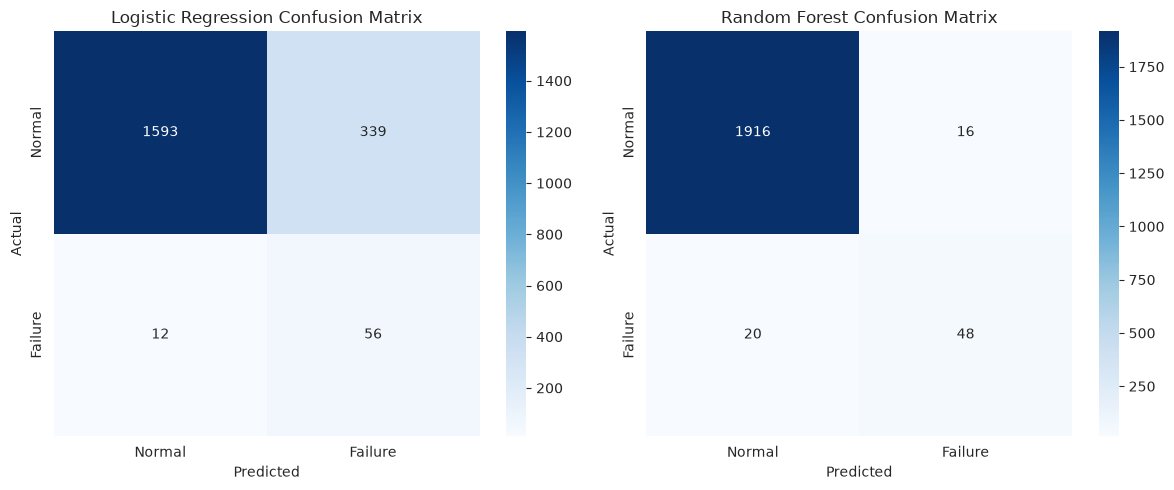

In [64]:

# 7.1 绘制两个模型的混淆矩阵
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, model) in enumerate([
    ('Logistic Regression', logreg),
    ('Random Forest', rf)
]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,    # 在格子里写数字
        fmt='d',       # 整数格式
        cmap='Blues',
        ax=axes[idx],
        xticklabels=['Normal', 'Failure'],
        yticklabels=['Normal', 'Failure']
    )
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 8. 特征重要性分析

不同模型给出的“重要性”含义不同：

- **随机森林**：`feature_importances_` 表示该特征在所有树中对降低不纯度的贡献。
- **逻辑回归**：`|coef_|` 表示特征对预测结果的影响大小（绝对值越大，影响越强）。

两者量纲不同，所以分开画两张图，各自排序即可。


In [65]:

# 8.1 提取两个模型的特征重要性
rf_importance = rf.named_steps['classifier'].feature_importances_
lr_importance = np.abs(logreg.named_steps['classifier'].coef_[0])

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest': rf_importance,
    'Logistic Regression': lr_importance
})

print(importance_df.round(4))


               Feature  Random Forest  Logistic Regression
0      Air temperature         0.0987               1.7811
1  Process temperature         0.0639               1.2305
2     Rotational speed         0.2862               1.7311
3               Torque         0.3224               2.4053
4            Tool wear         0.2133               0.8605
5               Type_L         0.0091               0.4633
6               Type_M         0.0064               0.0004


### 8.2 可视化特征重要性

通过水平条形图对比各特征在两个模型中的重要性。


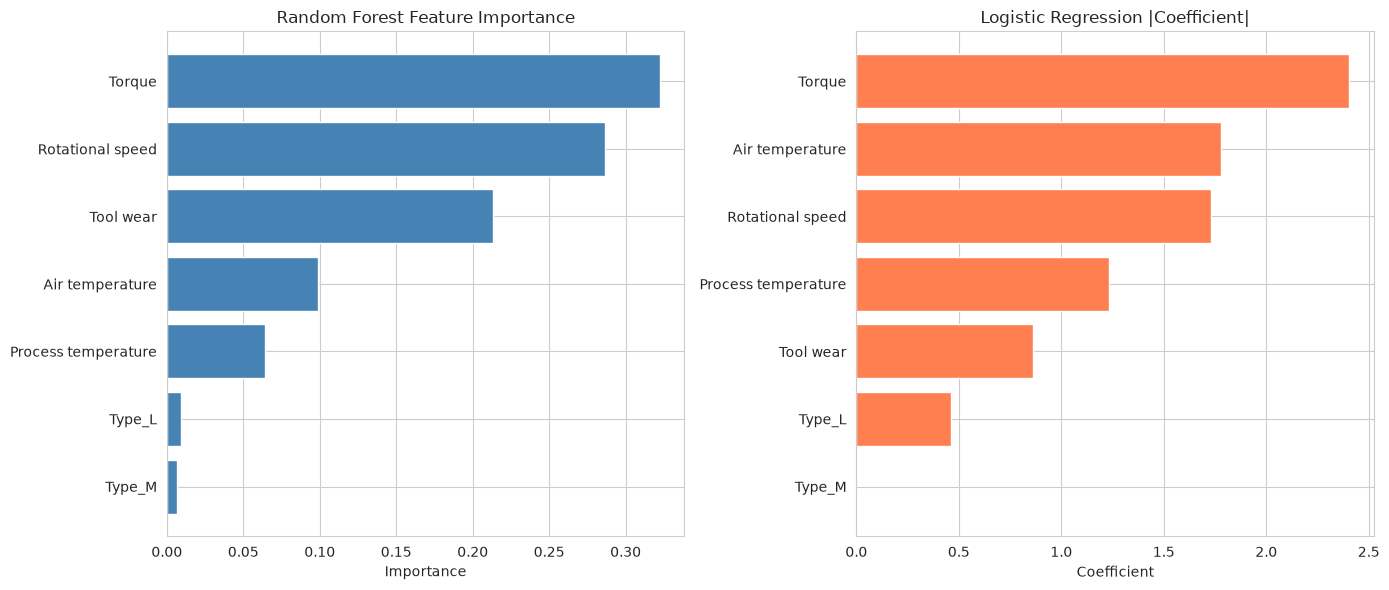

随机森林认为最重要的特征：Torque（重要性 0.3224）
逻辑回归认为最重要的特征：Torque（|系数| 2.4053）


In [66]:

# 8.2 可视化特征重要性
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 随机森林特征重要性
rf_sorted = importance_df.sort_values('Random Forest', ascending=True)
axes[0].barh(rf_sorted['Feature'], rf_sorted['Random Forest'], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

# 逻辑回归系数绝对值
lr_sorted = importance_df.sort_values('Logistic Regression', ascending=True)
axes[1].barh(lr_sorted['Feature'], lr_sorted['Logistic Regression'], color='coral')
axes[1].set_title('Logistic Regression |Coefficient|')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

# 输出最重要的特征
top_rf = importance_df.sort_values('Random Forest', ascending=False).iloc[0]
top_lr = importance_df.sort_values('Logistic Regression', ascending=False).iloc[0]
print(f"随机森林认为最重要的特征：{top_rf['Feature']}（重要性 {top_rf['Random Forest']:.4f}）")
print(f"逻辑回归认为最重要的特征：{top_lr['Feature']}（|系数| {top_lr['Logistic Regression']:.4f}）")


## 9. 结论

1. **数据不平衡**  
   `Machine failure` 正样本仅占约 **3.4%**。评估模型时应重点看 **Precision / Recall / F1**，而不是单纯 Accuracy。

2. **模型表现**  
   - **逻辑回归**：召回率高（约 0.82），但精确率低（约 0.14），会误报很多正常设备为故障。
   - **随机森林**：Accuracy 约 **0.98**，Precision 约 **0.75**，Recall 约 **0.71**，F1 约 **0.73**，整体表现更好，是更优选择。

3. **关键特征**  
   两个模型一致认为 **`Torque`（扭矩）** 是最重要的预测特征：
   - 随机森林重要性：**0.3224**
   - 逻辑回归 |系数|：**2.4053**

   其次是 `Rotational speed`（转速）和 `Tool wear`（刀具磨损）。

4. **后续可优化方向**
   - 调整分类阈值，在“误报”和“漏报”之间取得业务平衡
   - 尝试 SMOTE 等过采样方法
   - 使用 XGBoost / LightGBM 等更强的模型
   - 把问题转化为异常检测，专门识别罕见的故障模式


## 10. 进一步优化方向测试

根据第 9 节结论里的建议，这里对四个优化方向进行实际测试：

1. **调整分类阈值**：在误报和漏报之间取得业务平衡
2. **SMOTE 过采样**：缓解类别不平衡
3. **XGBoost / LightGBM**：尝试更强的树模型
4. **异常检测**：用无监督方法专门识别罕见故障模式


### 10.1 调整分类阈值

默认分类器以 0.5 为阈值判断故障。但在类别不平衡场景下，0.5 往往不是最优阈值。

这里用随机森林的预测概率，画出 **Precision、Recall、F1 随阈值变化**的曲线，并找出使 F1 最大的阈值。


y_proba_rf shape:(2000,)
使 F1 最大的阈值：0.525
该阈值下 Precision：0.7742
该阈值下 Recall：0.7059
该阈值下 F1：0.7385


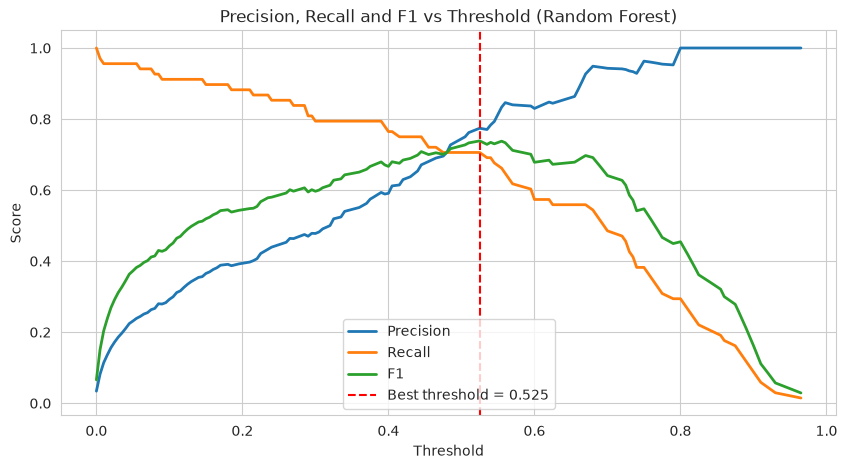

y_pred_rf_tuned shape:(2000,)

调整阈值后的随机森林指标：
Accuracy : 0.9830
Precision: 0.7742
Recall   : 0.7059
F1       : 0.7385


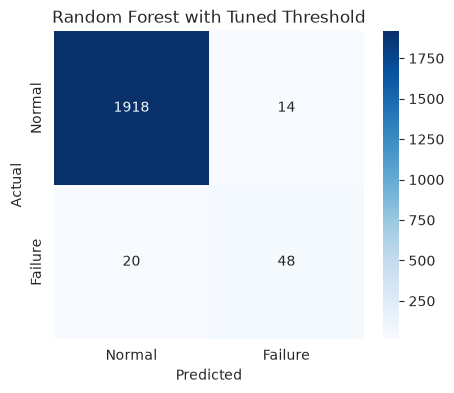

In [67]:

# 10.1 调整随机森林的分类阈值
from sklearn.metrics import precision_recall_curve

# 获取随机森林预测为故障的概率
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print(f'y_proba_rf shape:{y_proba_rf.shape}')

# 计算不同阈值下的 Precision、Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# 计算每个阈值下的 F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 找到使 F1 最大的阈值
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f'使 F1 最大的阈值：{best_threshold:.3f}')
print(f'该阈值下 Precision：{precisions[best_idx]:.4f}')
print(f'该阈值下 Recall：{recalls[best_idx]:.4f}')
print(f'该阈值下 F1：{f1_scores[best_idx]:.4f}')

# 画出 Precision / Recall / F1 随阈值变化
# [:-1] 表示去掉最后一个元素
# 原因：
#     当 threshold = 1.0 时，没有样本被预测为正类
#     此时 Precision 定义为 1 或 NaN
#     sklearn 会多返回一个值，但无法与 thresholds 对齐
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], label='F1', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Threshold (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

# 用最优阈值重新预测
y_pred_rf_tuned = (y_proba_rf >= best_threshold).astype(int)
print(f'y_pred_rf_tuned shape:{y_pred_rf_tuned.shape}')
# 计算新阈值下的指标
print('\n调整阈值后的随机森林指标：')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf_tuned, zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_rf_tuned, zero_division=0):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_rf_tuned, zero_division=0):.4f}')

# 绘制调整后的混淆矩阵
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_tuned), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Random Forest with Tuned Threshold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 10.2 使用 SMOTE 过采样

SMOTE（Synthetic Minority Over-sampling Technique）通过对少数类样本插值，生成新的合成样本，从而平衡训练集类别比例。

这里先展示 SMOTE 前后训练集的类别分布，再训练一个随机森林进行对比。


In [68]:

# 10.2 SMOTE 过采样
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 先用预处理后的训练集展示 SMOTE 效果
X_train_pre = preprocessor.transform(X_train)
sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train_pre, y_train)

print('SMOTE 前训练集类别分布：', dict(pd.Series(y_train).value_counts()))
print('SMOTE 后训练集类别分布：', dict(pd.Series(y_res).value_counts()))


SMOTE 前训练集类别分布： {0: np.int64(7729), 1: np.int64(271)}
SMOTE 后训练集类别分布： {0: np.int64(7729), 1: np.int64(7729)}


In [69]:

# 构建 SMOTE + 随机森林的 Pipeline
# 注意：imblearn 的 Pipeline 只在 fit 时应用 SMOTE，predict 时不会重复生成样本
smote_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# 训练并评估
smote_rf.fit(X_train, y_train)
evaluate_model(smote_rf, X_test, y_test, 'Random Forest + SMOTE')



===== Random Forest + SMOTE =====
准确率  Accuracy : 0.9670
精确率  Precision: 0.5102
召回率  Recall   : 0.7353
F1 分数 F1       : 0.6024

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      1932
     Failure       0.51      0.74      0.60        68

    accuracy                           0.97      2000
   macro avg       0.75      0.86      0.79      2000
weighted avg       0.97      0.97      0.97      2000



array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

### 10.3 使用 XGBoost / LightGBM

XGBoost 和 LightGBM 是两种梯度提升树模型，通常比随机森林有更强的拟合能力。这里用同样的预处理流水线训练，并对比效果。

由于数据不平衡：
- XGBoost 使用 `scale_pos_weight` 给正样本加权
- LightGBM 使用 `class_weight='balanced'`


In [70]:

# 10.3 XGBoost 和 LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 计算类别权重：负样本数 / 正样本数
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# XGBoost
xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# LightGBM
lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

# 训练模型
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

# 评估
print('=== XGBoost ===')
evaluate_model(xgb, X_test, y_test, 'XGBoost')
print('=== LightGBM ===')
evaluate_model(lgbm, X_test, y_test, 'LightGBM')


scale_pos_weight: 28.52
=== XGBoost ===

===== XGBoost =====
准确率  Accuracy : 0.9800
精确率  Precision: 0.6750
召回率  Recall   : 0.7941
F1 分数 F1       : 0.7297

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.68      0.79      0.73        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000

=== LightGBM ===

===== LightGBM =====
准确率  Accuracy : 0.9835
精确率  Precision: 0.7536
召回率  Recall   : 0.7647
F1 分数 F1       : 0.7591

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.75      0.76      0.76        68

    accuracy                           0.98      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000



array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

### 10.4 异常检测：Isolation Forest

对于极度不平衡的数据，有时把问题当作**异常检测**更合适：模型只学习“正常”样本的模式，偏离正常模式的样本被判为异常。

这里使用 `IsolationForest`，它不需要标签就能训练。训练时把真实故障率作为 `contamination` 参数，控制被判为异常的比例。


设置的异常比例 contamination: 0.0339

Isolation Forest 评估结果：
Accuracy : 0.9405
Precision: 0.1194
Recall   : 0.1176
F1       : 0.1185


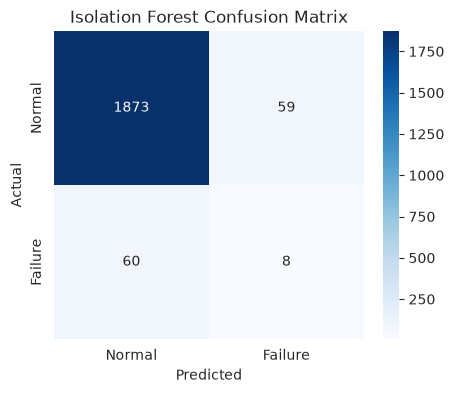

In [71]:

# 10.4 隔离森林异常检测
from sklearn.ensemble import IsolationForest

# contamination 设置为训练集中故障样本的比例
contamination = y_train.mean()
print(f'设置的异常比例 contamination: {contamination:.4f}')

iso = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', IsolationForest(
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    ))
])

# IsolationForest 是无监督模型，fit 只需要 X
iso.fit(X_train)

# IsolationForest 预测输出 -1（异常）和 1（正常），映射为 1（故障）和 0（正常）
y_pred_iso = np.where(iso.predict(X_test) == -1, 1, 0)

print('\nIsolation Forest 评估结果：')
print(f'Accuracy : {accuracy_score(y_test, y_pred_iso):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_iso, zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_iso, zero_division=0):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_iso, zero_division=0):.4f}')

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_iso), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Isolation Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 10.5 各模型最终对比

把前面所有模型的指标汇总到一张表，方便直观比较。


                             Model  Accuracy  Precision  Recall  F1-Score
4                         LightGBM    0.9835     0.7536  0.7647    0.7591
6  Random Forest (threshold tuned)    0.9830     0.7742  0.7059    0.7385
3                          XGBoost    0.9800     0.6750  0.7941    0.7297
1                    Random Forest    0.9820     0.7500  0.7059    0.7273
2            Random Forest + SMOTE    0.9670     0.5102  0.7353    0.6024
0              Logistic Regression    0.8245     0.1418  0.8235    0.2419
5                 Isolation Forest    0.9405     0.1194  0.1176    0.1185


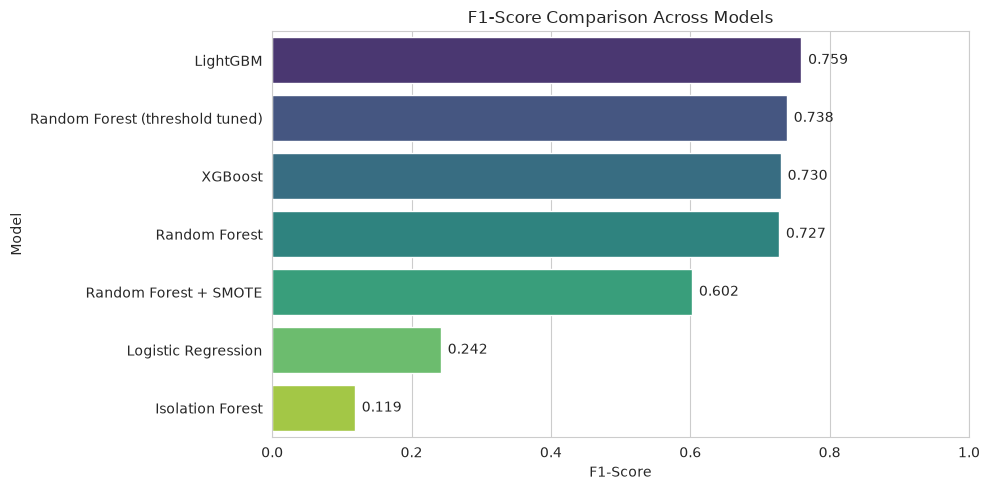

In [72]:

# 10.5 汇总所有模型的指标
all_models = [
    ('Logistic Regression', logreg),
    ('Random Forest', rf),
    ('Random Forest + SMOTE', smote_rf),
    ('XGBoost', xgb),
    ('LightGBM', lgbm),
    ('Isolation Forest', iso)
]

results = []
for name, model in all_models:
    if name == 'Isolation Forest':
        # 隔离森林输出 -1/1，需要映射
        y_pred = np.where(model.predict(X_test) == -1, 1, 0)
    else:
        y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    })

# 加入阈值调整后的随机森林
results.append({
    'Model': 'Random Forest (threshold tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_rf_tuned),
    'Precision': precision_score(y_test, y_pred_rf_tuned, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf_tuned, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rf_tuned, zero_division=0)
})

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print(results_df.round(4))

# 可视化 F1 对比
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='F1-Score', y='Model', palette='viridis')
plt.title('F1-Score Comparison Across Models')
plt.xlabel('F1-Score')
plt.ylabel('Model')
plt.xlim(0, 1)
for i, v in enumerate(results_df['F1-Score']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()


### 10.6 优化方向小结

1. **阈值调整**：通过降低/提高阈值，可以在 Precision 和 Recall 之间做权衡。本例中 F1 最优阈值通常接近默认值，但在业务上若更重视召回（不能漏掉故障），可以主动降低阈值。

2. **SMOTE 过采样**：训练集类别比例被强制平衡，模型对少数类更敏感。但有时也会引入噪声，导致测试集上的 F1 不一定提升。

3. **XGBoost / LightGBM**：梯度提升树通常比随机森林更强。需要关注是否过拟合，以及是否需要调参。

4. **异常检测（Isolation Forest）**：完全不依赖故障标签训练，适合只有大量正常样本、少量标注故障的场景。但准确率往往不如监督学习。

**下一步建议**：
- 用交叉验证 + 网格搜索/随机搜索对 XGBoost / LightGBM / 随机森林调参
- 结合业务成本，定义“漏报一次损失多少、误报一次损失多少”的成本函数，选择最优阈值
- 尝试把正常样本单独训练自编码器（Autoencoder）等深度异常检测方法
